# Spectrogram Gaussian Distance + XGBoost CPU

Pipeline: `WAV -> FFT/STFT -> Spectrogram -> Gaussian distance`.

Notebook nay self-contained de chay tren Kaggle CPU. Cell config ben duoi la noi can sua truoc khi train/EDA.

In [5]:
from pathlib import Path
from types import SimpleNamespace

# Kaggle notes:
# - DATA_ROOT=None lets the notebook auto-detect /kaggle/input/*/audio_visual_dataset_default/dataset.csv.
# - Set DATA_ROOT=Path("/kaggle/input/<your-dataset-folder>") if auto-detect picks the wrong dataset.
# - Set MAX_SAMPLES to a small number such as 80 for a quick smoke EDA run.
# - Keep TRAIN_XGBOOST=False for EDA-only; switch to True after the plots/features look useful.
DATA_ROOT = Path("/kaggle/input/datasets/duyem54/visual-audio/dataset")
OUTPUT_DIR = Path("/kaggle/working/gaussian_spectrogram")
MAX_SAMPLES = 0
TARGET_SR = 16000
WINDOW_SEC = 0.8
N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 128
N_MFCC = 40
CROP_MODE = "energy"
WEIGHT_MODE = "positive_shift"
SEED = 42
AUDIO_ONLY_INDEX = False
TRAIN_XGBOOST = False


In [6]:
from __future__ import annotations

import argparse
import json
import math
import sys
import wave
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import numpy as np
import pandas as pd


LABELS = ("ambient", "leaf", "trunk", "twig")
LABEL_TO_ID = {label: idx for idx, label in enumerate(LABELS)}
SPLITS = ("audio_visual_dataset_default", "audio_visual_dataset_robo_default")
PROJECT_ROOT = Path.cwd()
DEFAULT_OUTPUT_DIR = Path("/kaggle/working/gaussian_output")


@dataclass(frozen=True)
class FeatureConfig:
    target_sr: int = 16000
    window_sec: float = 0.8
    n_fft: int = 1024
    hop_length: int = 256
    n_mels: int = 128
    n_mfcc: int = 40
    crop_mode: str = "energy"
    weight_mode: str = "positive_shift"
    seed: int = 42


def tqdm_iter(iterable, **kwargs):
    try:
        from tqdm.auto import tqdm

        return tqdm(iterable, **kwargs)
    except Exception:
        return iterable


def find_data_root(data_root: str | Path | None = None) -> Path:
    def valid(root: Path) -> bool:
        return (root / "audio_visual_dataset_default" / "dataset.csv").exists()

    def expand(root: Path) -> list[Path]:
        return [
            root,
            root / "raw_dataset",
            root / "prepared_data",
            root / "dataset",
        ]

    candidates: list[Path] = []
    if data_root is not None:
        candidates.extend(expand(Path(data_root)))
    else:
        candidates.extend(
            [
                PROJECT_ROOT / "dataset",
                PROJECT_ROOT.parent / "dataset",
                Path("/kaggle/input/dataset"),
                Path("/kaggle/input/data"),
            ]
        )
        kaggle_input = Path("/kaggle/input")
        if kaggle_input.exists():
            for child in kaggle_input.iterdir():
                if child.is_dir():
                    candidates.extend(expand(child))

    for candidate in candidates:
        if valid(candidate):
            return candidate
    return candidates[0] if candidates else PROJECT_ROOT / "dataset"


def build_index(data_root: Path, skip_missing_files: bool = True, require_image: bool = True) -> pd.DataFrame:
    rows: list[dict] = []
    skipped = 0
    for split_name in SPLITS:
        split_dir = data_root / split_name
        csv_path = split_dir / "dataset.csv"
        if not csv_path.exists():
            continue
        frame = pd.read_csv(csv_path)
        for item in frame.to_dict("records"):
            audio_path = split_dir / str(item["audio_file"])
            image_path = split_dir / str(item.get("image_file", ""))
            audio_exists = audio_path.exists()
            image_exists = image_path.exists() if item.get("image_file") else False
            exists = audio_exists and (image_exists or not require_image)
            if skip_missing_files and not exists:
                skipped += 1
                continue
            label = str(item["category"])
            if label not in LABEL_TO_ID:
                skipped += 1
                continue
            rows.append(
                {
                    "split_name": split_name,
                    "split_role": "train" if split_name == SPLITS[0] else "val",
                    "audio_path": str(audio_path),
                    "image_path": str(image_path),
                    "label": label,
                    "label_id": LABEL_TO_ID[label],
                    "audio_exists": audio_exists,
                    "image_exists": image_exists,
                }
            )
    index = pd.DataFrame(rows)
    index.attrs["skipped_rows"] = skipped
    return index


def limit_index(index: pd.DataFrame, max_samples: int, seed: int) -> pd.DataFrame:
    if max_samples <= 0 or len(index) <= max_samples:
        return index.reset_index(drop=True)
    parts = []
    selected_indices: set[int] = set()
    rng = np.random.default_rng(seed)
    per_split = max(1, max_samples // max(1, index["split_role"].nunique()))
    for _, split_frame in index.groupby("split_role", sort=False):
        take = min(len(split_frame), per_split)
        chosen = rng.choice(split_frame.index.to_numpy(), size=take, replace=False)
        selected_indices.update(int(idx) for idx in chosen)
        parts.append(index.loc[chosen])
    limited = pd.concat(parts, ignore_index=True)
    if len(limited) < max_samples:
        remaining = index.drop(index=list(selected_indices), errors="ignore")
        if not remaining.empty:
            take = min(max_samples - len(limited), len(remaining))
            chosen = rng.choice(remaining.index.to_numpy(), size=take, replace=False)
            limited = pd.concat([limited, index.loc[chosen]], ignore_index=True)
    return limited.reset_index(drop=True)


def load_wav_mono(path: str | Path) -> tuple[np.ndarray, int]:
    path = Path(path)
    try:
        import soundfile as sf

        audio, sample_rate = sf.read(path, dtype="float32", always_2d=True)
        return audio.mean(axis=1).astype(np.float32), int(sample_rate)
    except Exception:
        pass

    try:
        import torchaudio

        waveform, sample_rate = torchaudio.load(str(path))
        audio = waveform.mean(dim=0).detach().cpu().numpy().astype(np.float32)
        return audio, int(sample_rate)
    except Exception:
        pass

    return load_wav_stdlib(path)


def load_wav_stdlib(path: Path) -> tuple[np.ndarray, int]:
    with wave.open(str(path), "rb") as wav:
        channels = wav.getnchannels()
        sample_rate = wav.getframerate()
        sample_width = wav.getsampwidth()
        frames = wav.readframes(wav.getnframes())

    if sample_width == 1:
        data = np.frombuffer(frames, dtype=np.uint8).astype(np.float32)
        data = (data - 128.0) / 128.0
    elif sample_width == 2:
        data = np.frombuffer(frames, dtype="<i2").astype(np.float32) / 32768.0
    elif sample_width == 3:
        raw = np.frombuffer(frames, dtype=np.uint8).reshape(-1, 3)
        signed = raw[:, 0].astype(np.int32) | (raw[:, 1].astype(np.int32) << 8) | (raw[:, 2].astype(np.int32) << 16)
        signed = np.where(signed & 0x800000, signed | ~0xFFFFFF, signed)
        data = signed.astype(np.float32) / 8388608.0
    elif sample_width == 4:
        data = np.frombuffer(frames, dtype="<i4").astype(np.float32) / 2147483648.0
    else:
        raise ValueError(f"Unsupported WAV sample width: {sample_width} bytes")

    if channels > 1:
        data = data.reshape(-1, channels).mean(axis=1)
    return data.astype(np.float32), int(sample_rate)


def resample_audio(audio: np.ndarray, orig_sr: int, target_sr: int) -> np.ndarray:
    if orig_sr == target_sr:
        return audio.astype(np.float32, copy=False)
    try:
        from scipy.signal import resample_poly

        gcd = math.gcd(orig_sr, target_sr)
        resampled = resample_poly(audio, target_sr // gcd, orig_sr // gcd)
        return resampled.astype(np.float32)
    except Exception:
        target_len = max(1, int(round(len(audio) * target_sr / orig_sr)))
        old_x = np.linspace(0.0, 1.0, num=len(audio), endpoint=False)
        new_x = np.linspace(0.0, 1.0, num=target_len, endpoint=False)
        return np.interp(new_x, old_x, audio).astype(np.float32)


def crop_or_pad(audio: np.ndarray, target_samples: int, mode: str, rng: np.random.Generator) -> np.ndarray:
    if len(audio) < target_samples:
        return np.pad(audio, (0, target_samples - len(audio))).astype(np.float32)
    if len(audio) == target_samples:
        return audio.astype(np.float32, copy=False)

    max_start = len(audio) - target_samples
    if mode == "random":
        start = int(rng.integers(0, max_start + 1))
    elif mode == "energy":
        squared = audio.astype(np.float64) ** 2
        cumsum = np.concatenate([[0.0], np.cumsum(squared)])
        energy = cumsum[target_samples:] - cumsum[:-target_samples]
        start = int(np.argmax(energy))
    else:
        start = max_start // 2
    return audio[start : start + target_samples].astype(np.float32)


def load_audio_window(path: str | Path, cfg: FeatureConfig, rng: np.random.Generator) -> np.ndarray:
    audio, sample_rate = load_wav_mono(path)
    audio = resample_audio(audio, sample_rate, cfg.target_sr)
    target_samples = int(round(cfg.target_sr * cfg.window_sec))
    return crop_or_pad(audio, target_samples, cfg.crop_mode, rng)


def stft_power_spectrogram(audio: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    n_fft = cfg.n_fft
    hop = cfg.hop_length
    if len(audio) < n_fft:
        audio = np.pad(audio, (0, n_fft - len(audio)))
    frame_count = 1 + max(0, (len(audio) - n_fft) // hop)
    starts = np.arange(frame_count) * hop
    window = np.hanning(n_fft).astype(np.float32)
    frames = np.stack([audio[start : start + n_fft] for start in starts], axis=0)
    spectrum = np.fft.rfft(frames * window[None, :], n=n_fft, axis=1)
    power = (np.abs(spectrum) ** 2).astype(np.float32)
    return power.T


def power_to_db(power: np.ndarray, amin: float = 1e-10) -> np.ndarray:
    return (10.0 * np.log10(np.maximum(power, amin))).astype(np.float32)


def hz_to_mel(freq: np.ndarray | float) -> np.ndarray | float:
    return 2595.0 * np.log10(1.0 + np.asarray(freq) / 700.0)


def mel_to_hz(mel: np.ndarray | float) -> np.ndarray | float:
    return 700.0 * (10.0 ** (np.asarray(mel) / 2595.0) - 1.0)


def mel_filter_bank(sample_rate: int, n_fft: int, n_mels: int, fmin: float = 0.0, fmax: float | None = None) -> np.ndarray:
    fmax = fmax or sample_rate / 2.0
    mel_points = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((n_fft + 1) * hz_points / sample_rate).astype(int)
    max_bin = n_fft // 2
    bins = np.clip(bins, 0, max_bin)
    filters = np.zeros((n_mels, max_bin + 1), dtype=np.float32)

    for mel_idx in range(1, n_mels + 1):
        left, center, right = bins[mel_idx - 1], bins[mel_idx], bins[mel_idx + 1]
        center = max(center, left + 1)
        right = max(right, center + 1)
        right = min(right, max_bin)
        for freq_bin in range(left, center):
            filters[mel_idx - 1, freq_bin] = (freq_bin - left) / max(1, center - left)
        for freq_bin in range(center, right + 1):
            filters[mel_idx - 1, freq_bin] = (right - freq_bin) / max(1, right - center)

    enorm = 2.0 / np.maximum(1e-10, hz_points[2 : n_mels + 2] - hz_points[:n_mels])
    filters *= enorm[:, None]
    return filters


def dct_type_ii(matrix: np.ndarray, n_coeffs: int) -> np.ndarray:
    rows = matrix.shape[0]
    coeffs = min(n_coeffs, rows)
    basis = np.cos(np.pi / rows * (np.arange(rows)[None, :] + 0.5) * np.arange(coeffs)[:, None])
    basis[0, :] *= math.sqrt(1.0 / rows)
    if coeffs > 1:
        basis[1:, :] *= math.sqrt(2.0 / rows)
    return (basis @ matrix).astype(np.float32)


def map_to_weights(feature_map: np.ndarray, mode: str) -> np.ndarray:
    values = np.nan_to_num(feature_map.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
    if mode == "absolute":
        weights = np.abs(values)
    elif mode == "softmax":
        shifted = np.clip(values - np.max(values), -60.0, 60.0)
        weights = np.exp(shifted)
    else:
        weights = values - np.min(values)
    if not np.isfinite(weights).all() or float(weights.sum()) <= 1e-12:
        weights = np.ones_like(values, dtype=np.float64)
    weights = weights + 1e-12
    return weights / weights.sum()


def weighted_gaussian_from_map(feature_map: np.ndarray, weight_mode: str) -> dict:
    weights = map_to_weights(feature_map, weight_mode)
    freq_bins, time_bins = weights.shape
    freq_coord = np.linspace(0.0, 1.0, freq_bins, dtype=np.float64)[:, None]
    time_coord = np.linspace(0.0, 1.0, time_bins, dtype=np.float64)[None, :]

    mu_freq = float(np.sum(weights * freq_coord))
    mu_time = float(np.sum(weights * time_coord))
    df = freq_coord - mu_freq
    dt = time_coord - mu_time
    cov_ff = float(np.sum(weights * df * df) + 1e-6)
    cov_tt = float(np.sum(weights * dt * dt) + 1e-6)
    cov_ft = float(np.sum(weights * df * dt))
    corr = cov_ft / math.sqrt(max(cov_ff * cov_tt, 1e-12))
    cov = np.array([[cov_ff, cov_ft], [cov_ft, cov_tt]], dtype=np.float64)
    cov = regularize_cov(cov)
    sign, logdet = np.linalg.slogdet(cov)
    entropy = 0.5 * math.log(max((2.0 * math.pi * math.e) ** 2 * np.linalg.det(cov), 1e-12))

    return {
        "mu_freq": mu_freq,
        "mu_time": mu_time,
        "cov_ff": float(cov[0, 0]),
        "cov_ft": float(cov[0, 1]),
        "cov_tt": float(cov[1, 1]),
        "std_freq": float(math.sqrt(max(cov[0, 0], 0.0))),
        "std_time": float(math.sqrt(max(cov[1, 1], 0.0))),
        "corr": float(corr),
        "logdet": float(logdet if sign > 0 else math.log(1e-12)),
        "entropy": float(entropy),
    }


def map_summary(feature_map: np.ndarray) -> dict:
    values = np.nan_to_num(feature_map.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
    return {
        "map_rows": int(values.shape[0]),
        "map_cols": int(values.shape[1]),
        "map_mean": float(values.mean()),
        "map_std": float(values.std()),
        "map_min": float(values.min()),
        "map_max": float(values.max()),
        "map_p10": float(np.percentile(values, 10)),
        "map_p50": float(np.percentile(values, 50)),
        "map_p90": float(np.percentile(values, 90)),
        "map_energy": float(np.square(values).mean()),
    }


def row_to_gaussian(row: pd.Series | dict) -> tuple[np.ndarray, np.ndarray]:
    mu = np.array([float(row["mu_freq"]), float(row["mu_time"])], dtype=np.float64)
    cov = np.array(
        [
            [float(row["cov_ff"]), float(row["cov_ft"])],
            [float(row["cov_ft"]), float(row["cov_tt"])],
        ],
        dtype=np.float64,
    )
    return mu, regularize_cov(cov)


def regularize_cov(cov: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    cov = 0.5 * (cov + cov.T)
    eigvals = np.linalg.eigvalsh(cov)
    min_eig = float(eigvals.min())
    if min_eig < eps:
        cov = cov + np.eye(cov.shape[0]) * (eps - min_eig)
    return cov


def kl_gaussian(mu_p: np.ndarray, cov_p: np.ndarray, mu_q: np.ndarray, cov_q: np.ndarray) -> float:
    cov_p = regularize_cov(cov_p)
    cov_q = regularize_cov(cov_q)
    inv_q = np.linalg.inv(cov_q)
    diff = mu_q - mu_p
    dim = len(mu_p)
    sign_p, logdet_p = np.linalg.slogdet(cov_p)
    sign_q, logdet_q = np.linalg.slogdet(cov_q)
    if sign_p <= 0 or sign_q <= 0:
        return float("inf")
    value = 0.5 * (np.trace(inv_q @ cov_p) + diff.T @ inv_q @ diff - dim + logdet_q - logdet_p)
    return float(max(value, 0.0))


def symmetric_kl(mu_a: np.ndarray, cov_a: np.ndarray, mu_b: np.ndarray, cov_b: np.ndarray) -> float:
    return 0.5 * (kl_gaussian(mu_a, cov_a, mu_b, cov_b) + kl_gaussian(mu_b, cov_b, mu_a, cov_a))


def bhattacharyya_distance(mu_a: np.ndarray, cov_a: np.ndarray, mu_b: np.ndarray, cov_b: np.ndarray) -> float:
    cov_mean = regularize_cov(0.5 * (cov_a + cov_b))
    diff = mu_b - mu_a
    sign_mean, logdet_mean = np.linalg.slogdet(cov_mean)
    sign_a, logdet_a = np.linalg.slogdet(regularize_cov(cov_a))
    sign_b, logdet_b = np.linalg.slogdet(regularize_cov(cov_b))
    if sign_mean <= 0 or sign_a <= 0 or sign_b <= 0:
        return float("inf")
    mahal = 0.125 * float(diff.T @ np.linalg.inv(cov_mean) @ diff)
    det_term = 0.5 * (logdet_mean - 0.5 * (logdet_a + logdet_b))
    return float(max(mahal + det_term, 0.0))


def spd_sqrtm(matrix: np.ndarray) -> np.ndarray:
    eigvals, eigvecs = np.linalg.eigh(regularize_cov(matrix))
    eigvals = np.clip(eigvals, 1e-12, None)
    return (eigvecs * np.sqrt(eigvals)) @ eigvecs.T


def wasserstein2_distance(mu_a: np.ndarray, cov_a: np.ndarray, mu_b: np.ndarray, cov_b: np.ndarray) -> float:
    sqrt_a = spd_sqrtm(cov_a)
    middle = spd_sqrtm(sqrt_a @ regularize_cov(cov_b) @ sqrt_a)
    mean_term = float(np.sum((mu_a - mu_b) ** 2))
    cov_term = float(np.trace(regularize_cov(cov_a) + regularize_cov(cov_b) - 2.0 * middle))
    return float(math.sqrt(max(mean_term + cov_term, 0.0)))


def fit_class_gaussians(train_rows: pd.DataFrame) -> dict[str, dict]:
    prototypes: dict[str, dict] = {}
    for label in LABELS:
        label_rows = train_rows[train_rows["label"] == label]
        if label_rows.empty:
            continue
        mus = []
        covs = []
        for _, row in label_rows.iterrows():
            mu, cov = row_to_gaussian(row)
            mus.append(mu)
            covs.append(cov)
        mu_stack = np.stack(mus, axis=0)
        mean_mu = mu_stack.mean(axis=0)
        within_cov = np.stack(covs, axis=0).mean(axis=0)
        between_cov = np.cov(mu_stack.T, bias=True) if len(mu_stack) > 1 else np.zeros((2, 2), dtype=np.float64)
        proto_cov = regularize_cov(within_cov + between_cov)
        prototypes[label] = {"mu": mean_mu, "cov": proto_cov, "count": int(len(label_rows))}
    return prototypes


def add_distance_columns(rows: pd.DataFrame, prototypes: dict[str, dict]) -> pd.DataFrame:
    output = rows.copy()
    for label in LABELS:
        if label not in prototypes:
            continue
        output[f"skl_to_{label}"] = np.nan
        output[f"bhat_to_{label}"] = np.nan
        output[f"w2_to_{label}"] = np.nan

    for idx, row in output.iterrows():
        mu, cov = row_to_gaussian(row)
        best_label = None
        best_bhat = float("inf")
        for label, proto in prototypes.items():
            proto_mu = proto["mu"]
            proto_cov = proto["cov"]
            skl = symmetric_kl(mu, cov, proto_mu, proto_cov)
            bhat = bhattacharyya_distance(mu, cov, proto_mu, proto_cov)
            w2 = wasserstein2_distance(mu, cov, proto_mu, proto_cov)
            output.at[idx, f"skl_to_{label}"] = skl
            output.at[idx, f"bhat_to_{label}"] = bhat
            output.at[idx, f"w2_to_{label}"] = w2
            if bhat < best_bhat:
                best_bhat = bhat
                best_label = label
        output.at[idx, "nearest_gaussian_label"] = best_label
        output.at[idx, "nearest_gaussian_bhat"] = best_bhat
    return output


def extract_gaussian_rows(
    index: pd.DataFrame,
    feature_name: str,
    extract_map: Callable[[np.ndarray, FeatureConfig], np.ndarray],
    cfg: FeatureConfig,
) -> tuple[pd.DataFrame, list[dict]]:
    rows: list[dict] = []
    failures: list[dict] = []
    rng = np.random.default_rng(cfg.seed)
    records = index.to_dict("records")
    for sample_id, item in enumerate(tqdm_iter(records, desc=f"{feature_name} maps", leave=False)):
        try:
            audio = load_audio_window(item["audio_path"], cfg, rng)
            feature_map = extract_map(audio, cfg)
            stats = weighted_gaussian_from_map(feature_map, cfg.weight_mode)
            summary = map_summary(feature_map)
            rows.append(
                {
                    "sample_id": sample_id,
                    "split_name": item["split_name"],
                    "split_role": item["split_role"],
                    "audio_path": item["audio_path"],
                    "label": item["label"],
                    "label_id": item["label_id"],
                    "feature": feature_name,
                    **stats,
                    **summary,
                }
            )
        except Exception as exc:
            failures.append({"audio_path": item.get("audio_path"), "error": repr(exc)})
    return pd.DataFrame(rows), failures


def gaussian_feature_columns(frame: pd.DataFrame) -> list[str]:
    base = [
        "mu_freq",
        "mu_time",
        "cov_ff",
        "cov_ft",
        "cov_tt",
        "std_freq",
        "std_time",
        "corr",
        "logdet",
        "entropy",
        "map_mean",
        "map_std",
        "map_min",
        "map_max",
        "map_p10",
        "map_p50",
        "map_p90",
        "map_energy",
    ]
    distance_cols = [
        col
        for col in frame.columns
        if col.startswith("skl_to_") or col.startswith("bhat_to_") or col.startswith("w2_to_")
    ]
    return [col for col in [*base, *distance_cols] if col in frame.columns]


def run_xgboost_baseline(frame: pd.DataFrame, output_dir: Path, feature_name: str, seed: int) -> dict:
    try:
        from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
        from sklearn.model_selection import train_test_split
        from xgboost import XGBClassifier
    except Exception as exc:
        raise RuntimeError("xgboost and scikit-learn are required for --train-xgboost") from exc

    feature_cols = gaussian_feature_columns(frame)
    train_frame = frame[frame["split_role"] == "train"].reset_index(drop=True)
    val_frame = frame[frame["split_role"] == "val"].reset_index(drop=True)
    if train_frame.empty:
        raise ValueError("No training rows were found.")
    if val_frame.empty:
        train_frame, val_frame = train_test_split(
            train_frame,
            test_size=0.2,
            random_state=seed,
            stratify=train_frame["label_id"] if train_frame["label_id"].nunique() > 1 else None,
        )

    x_train = np.nan_to_num(train_frame[feature_cols].to_numpy(np.float32))
    y_train = train_frame["label_id"].to_numpy()
    x_val = np.nan_to_num(val_frame[feature_cols].to_numpy(np.float32))
    y_val = val_frame["label_id"].to_numpy()

    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softmax",
        num_class=len(LABELS),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=seed,
        n_jobs=-1,
    )
    model.fit(x_train, y_train)
    pred = model.predict(x_val)
    metrics = {
        "feature": feature_name,
        "classifier": "xgboost",
        "xgboost_params": model.get_xgb_params(),
        "feature_columns": feature_cols,
        "accuracy": float(accuracy_score(y_val, pred)),
        "macro_f1": float(f1_score(y_val, pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_val, pred, average="weighted", zero_division=0)),
        "binary_contact_f1": float(f1_score(y_val != LABEL_TO_ID["ambient"], pred != LABEL_TO_ID["ambient"], zero_division=0)),
        "classification_report": classification_report(
            y_val,
            pred,
            labels=list(range(len(LABELS))),
            target_names=LABELS,
            output_dict=True,
            zero_division=0,
        ),
        "confusion_matrix": confusion_matrix(y_val, pred, labels=list(range(len(LABELS)))).tolist(),
    }
    metrics_path = output_dir / f"{feature_name}_gaussian_distance_xgboost_metrics.json"
    metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    return metrics


def prototype_to_jsonable(prototypes: dict[str, dict]) -> dict:
    return {
        label: {
            "count": proto["count"],
            "mu": proto["mu"].tolist(),
            "cov": proto["cov"].tolist(),
        }
        for label, proto in prototypes.items()
    }


def write_eda_outputs(
    frame: pd.DataFrame,
    failures: list[dict],
    prototypes: dict[str, dict],
    output_dir: Path,
    feature_name: str,
    cfg: FeatureConfig,
    skipped_rows: int,
) -> dict:
    output_dir.mkdir(parents=True, exist_ok=True)
    feature_csv = output_dir / f"{feature_name}_gaussian_distance_features.csv"
    summary_json = output_dir / f"{feature_name}_gaussian_distance_summary.json"
    prototype_json = output_dir / f"{feature_name}_gaussian_distance_prototypes.json"
    distance_csv = output_dir / f"{feature_name}_gaussian_distance_by_label.csv"
    failure_json = output_dir / f"{feature_name}_gaussian_distance_failures.json"

    frame.to_csv(feature_csv, index=False)
    if not frame.empty:
        distance_cols = [col for col in frame.columns if col.startswith(("skl_to_", "bhat_to_", "w2_to_"))]
        grouped = frame.groupby(["split_role", "label"])[distance_cols].mean().reset_index()
        grouped.to_csv(distance_csv, index=False)

    summary = {
        "feature": feature_name,
        "rows": int(len(frame)),
        "train_rows": int((frame["split_role"] == "train").sum()) if not frame.empty else 0,
        "val_rows": int((frame["split_role"] == "val").sum()) if not frame.empty else 0,
        "labels": LABELS,
        "config": cfg.__dict__,
        "skipped_index_rows": int(skipped_rows),
        "failed_feature_rows": int(len(failures)),
        "outputs": {
            "features_csv": str(feature_csv),
            "distance_by_label_csv": str(distance_csv),
            "prototypes_json": str(prototype_json),
            "failures_json": str(failure_json) if failures else None,
        },
    }
    summary_json.write_text(json.dumps(summary, indent=2), encoding="utf-8")
    prototype_json.write_text(json.dumps(prototype_to_jsonable(prototypes), indent=2), encoding="utf-8")
    if failures:
        failure_json.write_text(json.dumps(failures, indent=2), encoding="utf-8")
    plot_eda(frame, output_dir, feature_name)
    return summary


def plot_eda(frame: pd.DataFrame, output_dir: Path, feature_name: str) -> None:
    if frame.empty:
        return
    try:
        import matplotlib.pyplot as plt
    except Exception:
        return

    colors = {
        "ambient": "#4c78a8",
        "leaf": "#59a14f",
        "trunk": "#9c755f",
        "twig": "#f28e2b",
    }
    fig, ax = plt.subplots(figsize=(7, 5), dpi=140)
    for label in LABELS:
        part = frame[frame["label"] == label]
        if part.empty:
            continue
        ax.scatter(part["mu_time"], part["mu_freq"], s=18, alpha=0.7, label=label, color=colors.get(label))
    ax.set_xlabel("Gaussian mean on time axis")
    ax.set_ylabel("Gaussian mean on frequency/feature axis")
    ax.set_title(f"{feature_name}: 2D Gaussian centers")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(output_dir / f"{feature_name}_gaussian_mu_scatter.png")
    plt.close(fig)

    own_distances = []
    labels = []
    for _, row in frame.iterrows():
        col = f"bhat_to_{row['label']}"
        if col in frame.columns:
            own_distances.append(float(row[col]))
            labels.append(row["label"])
    if own_distances:
        box_data = []
        box_labels = []
        for target in LABELS:
            values = np.asarray([value for value, label in zip(own_distances, labels) if label == target])
            if values.size:
                box_data.append(values)
                box_labels.append(target)
        fig, ax = plt.subplots(figsize=(7, 5), dpi=140)
        ax.boxplot(box_data, labels=box_labels, showfliers=False)
        ax.set_ylabel("Bhattacharyya distance to own class prototype")
        ax.set_title(f"{feature_name}: within-class Gaussian distance")
        fig.tight_layout()
        fig.savefig(output_dir / f"{feature_name}_gaussian_own_distance_boxplot.png")
        plt.close(fig)


def build_spectrogram_map(audio: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    power = stft_power_spectrogram(audio, cfg)
    return np.log1p(power).astype(np.float32)


def make_parser(description: str, default_weight_mode: str) -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(description=description)
    parser.add_argument("--data-root", type=Path, default=None, help="Dataset root containing audio_visual_dataset_* folders.")
    parser.add_argument("--output-dir", type=Path, default=DEFAULT_OUTPUT_DIR, help="Where EDA CSV/JSON/plots are written.")
    parser.add_argument("--max-samples", type=int, default=0, help="Optional cap for quick EDA smoke runs. 0 means all rows.")
    parser.add_argument("--target-sr", type=int, default=16000)
    parser.add_argument("--window-sec", type=float, default=0.8)
    parser.add_argument("--n-fft", type=int, default=1024)
    parser.add_argument("--hop-length", type=int, default=256)
    parser.add_argument("--n-mels", type=int, default=128)
    parser.add_argument("--n-mfcc", type=int, default=40)
    parser.add_argument("--crop-mode", choices=("energy", "center", "random"), default="energy")
    parser.add_argument("--weight-mode", choices=("positive_shift", "absolute", "softmax"), default=default_weight_mode)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--audio-only-index", action="store_true", help="Do not require image files while building the index.")
    parser.add_argument("--train-xgboost", action="store_true", help="Fit the CPU XGBoost head on Gaussian-distance features.")
    return parser


def run_pipeline(
    feature_name: str,
    extract_map: Callable[[np.ndarray, FeatureConfig], np.ndarray],
    args: argparse.Namespace,
) -> dict:
    data_root = find_data_root(args.data_root)
    if not (data_root / "audio_visual_dataset_default" / "dataset.csv").exists():
        raise FileNotFoundError(
            f"Could not find dataset.csv under {data_root}. Pass --data-root to the released processed dataset root."
        )
    cfg = FeatureConfig(
        target_sr=args.target_sr,
        window_sec=args.window_sec,
        n_fft=args.n_fft,
        hop_length=args.hop_length,
        n_mels=args.n_mels,
        n_mfcc=args.n_mfcc,
        crop_mode=args.crop_mode,
        weight_mode=args.weight_mode,
        seed=args.seed,
    )
    index = build_index(data_root, skip_missing_files=True, require_image=not args.audio_only_index)
    index = limit_index(index, args.max_samples, args.seed)
    if index.empty:
        raise ValueError(f"No usable rows found under {data_root}")

    feature_rows, failures = extract_gaussian_rows(index, feature_name, extract_map, cfg)
    if feature_rows.empty:
        raise ValueError("All feature extraction rows failed. Check the failures JSON or audio dependencies.")

    train_rows = feature_rows[feature_rows["split_role"] == "train"]
    if train_rows.empty:
        train_rows = feature_rows
    prototypes = fit_class_gaussians(train_rows)
    feature_rows = add_distance_columns(feature_rows, prototypes)
    summary = write_eda_outputs(
        feature_rows,
        failures,
        prototypes,
        args.output_dir,
        feature_name,
        cfg,
        int(index.attrs.get("skipped_rows", 0)),
    )
    if args.train_xgboost:
        metrics = run_xgboost_baseline(feature_rows, args.output_dir, feature_name, args.seed)
        summary["xgboost_metrics"] = {
            "accuracy": metrics["accuracy"],
            "macro_f1": metrics["macro_f1"],
            "weighted_f1": metrics["weighted_f1"],
            "binary_contact_f1": metrics["binary_contact_f1"],
        }
    print(json.dumps(summary, indent=2))
    return summary


In [7]:
args = SimpleNamespace(
    data_root=DATA_ROOT,
    output_dir=OUTPUT_DIR,
    max_samples=MAX_SAMPLES,
    target_sr=TARGET_SR,
    window_sec=WINDOW_SEC,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    n_mfcc=N_MFCC,
    crop_mode=CROP_MODE,
    weight_mode=WEIGHT_MODE,
    seed=SEED,
    audio_only_index=AUDIO_ONLY_INDEX,
    train_xgboost=TRAIN_XGBOOST,
)

summary = run_pipeline("spectrogram", build_spectrogram_map, args)
summary


spectrogram maps:   0%|          | 0/12894 [00:00<?, ?it/s]

/tmp/ipykernel_57/1760589951.py:703: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=box_labels, showfliers=False)


{
  "feature": "spectrogram",
  "rows": 12894,
  "train_rows": 10676,
  "val_rows": 2218,
  "labels": [
    "ambient",
    "leaf",
    "trunk",
    "twig"
  ],
  "config": {
    "target_sr": 16000,
    "window_sec": 0.8,
    "n_fft": 1024,
    "hop_length": 256,
    "n_mels": 128,
    "n_mfcc": 40,
    "crop_mode": "energy",
    "weight_mode": "positive_shift",
    "seed": 42
  },
  "skipped_index_rows": 1,
  "failed_feature_rows": 0,
  "outputs": {
    "features_csv": "/kaggle/working/gaussian_spectrogram/spectrogram_gaussian_distance_features.csv",
    "distance_by_label_csv": "/kaggle/working/gaussian_spectrogram/spectrogram_gaussian_distance_by_label.csv",
    "prototypes_json": "/kaggle/working/gaussian_spectrogram/spectrogram_gaussian_distance_prototypes.json",
    "failures_json": null
  }
}


{'feature': 'spectrogram',
 'rows': 12894,
 'train_rows': 10676,
 'val_rows': 2218,
 'labels': ('ambient', 'leaf', 'trunk', 'twig'),
 'config': {'target_sr': 16000,
  'window_sec': 0.8,
  'n_fft': 1024,
  'hop_length': 256,
  'n_mels': 128,
  'n_mfcc': 40,
  'crop_mode': 'energy',
  'weight_mode': 'positive_shift',
  'seed': 42},
 'skipped_index_rows': 1,
 'failed_feature_rows': 0,
 'outputs': {'features_csv': '/kaggle/working/gaussian_spectrogram/spectrogram_gaussian_distance_features.csv',
  'distance_by_label_csv': '/kaggle/working/gaussian_spectrogram/spectrogram_gaussian_distance_by_label.csv',
  'prototypes_json': '/kaggle/working/gaussian_spectrogram/spectrogram_gaussian_distance_prototypes.json',
  'failures_json': None}}

## EDA preview

Cell nay doc lai CSV/plot vua tao de xem nhanh tren Kaggle. Khong can train XGBoost.

Feature rows: 12894


,sample_id,split_name,split_role,audio_path,label,label_id,feature,mu_freq,mu_time,cov_ff,...,bhat_to_leaf,w2_to_leaf,skl_to_trunk,bhat_to_trunk,w2_to_trunk,skl_to_twig,bhat_to_twig,w2_to_twig,nearest_gaussian_label,nearest_gaussian_bhat
0,0,audio_visual_dataset_default,train,/kaggle/input/datasets/duyem54/visual-audio/da...,ambient,0,spectrogram,0.014110,0.345072,0.009244,...,0.130615,0.197153,0.286311,0.068251,0.170722,0.456000,0.106906,0.185690,trunk,0.068251
1,1,audio_visual_dataset_default,train,/kaggle/input/datasets/duyem54/visual-audio/da...,ambient,0,spectrogram,0.018015,0.242507,0.012596,...,0.239240,0.305352,0.912086,0.186457,0.284918,1.241429,0.255192,0.301003,trunk,0.186457
2,2,audio_visual_dataset_default,train,/kaggle/input/datasets/duyem54/visual-audio/da...,ambient,0,spectrogram,0.007676,0.535871,0.003017,...,0.240600,0.109528,0.710311,0.137827,0.079718,0.381661,0.089816,0.060024,twig,0.089816
3,3,audio_visual_dataset_default,train,/kaggle/input/datasets/duyem54/visual-audio/da...,ambient,0,spectrogram,0.004589,0.684234,0.002114,...,0.369066,0.217136,1.432440,0.262217,0.212883,0.870529,0.194480,0.197059,twig,0.194480
4,4,audio_visual_dataset_default,train,/kaggle/input/datasets/duyem54/visual-audio/da...,ambient,0,spectrogram,0.134896,0.413496,0.063314,...,0.151033,0.176146,1.229180,0.207912,0.193634,3.043076,0.362004,0.224308,ambient,0.023547


mu_freq  mu_time  std_freq  std_time  entropy  \
split_role label                                                    
train      ambient   0.0877   0.4969    0.1680    0.2710  -0.4755   
           leaf      0.0911   0.5092    0.0814    0.2269  -1.5645   
           trunk     0.0523   0.4944    0.0509    0.2246  -2.0342   
           twig      0.0555   0.5067    0.0523    0.2285  -1.9402   
val        ambient   0.1203   0.5057    0.2046    0.2699  -0.2174   
           leaf      0.0255   0.4937    0.0325    0.2103  -2.8514   
           trunk     0.0310   0.4966    0.0541    0.2357  -2.5337   
           twig      0.0478   0.5108    0.0453    0.2072  -2.4700   

                    nearest_gaussian_bhat  
split_role label                           
train      ambient                 0.1620  
           leaf                    0.3217  
           trunk                   0.3914  
           twig                    0.3471  
val        ambient                 0.1523  
           leaf                    0.7549  
           trunk                   0.6886  
           twig                    0.5861

,split_role,label,skl_to_ambient,bhat_to_ambient,w2_to_ambient,skl_to_leaf,bhat_to_leaf,w2_to_leaf,skl_to_trunk,bhat_to_trunk,w2_to_trunk,skl_to_twig,bhat_to_twig,w2_to_twig
0,train,ambient,16.9062,0.2272,0.1754,13.8197,0.2382,0.1769,12.9819,0.2479,0.1743,13.8911,0.3427,0.1941
1,train,leaf,43.8023,0.5728,0.2875,17.9721,0.4176,0.2503,11.9799,0.4040,0.2500,8.1182,0.3902,0.2483
2,train,trunk,47.8469,0.7773,0.3058,19.4917,0.5757,0.2604,13.0673,0.5021,0.2501,8.6716,0.4195,0.2451
3,train,twig,27.4482,0.7195,0.2982,10.6294,0.5042,0.2517,7.2332,0.4421,0.2438,4.5483,0.3595,0.2382
4,val,ambient,9.3838,0.1739,0.1505,10.1178,0.2408,0.1840,10.4005,0.2801,0.1962,12.2760,0.4053,0.2204
5,val,leaf,192.4470,1.1724,0.3287,76.0477,0.9657,0.2816,47.9158,0.8593,0.2685,28.9293,0.7644,0.2617
6,val,trunk,181.2904,1.0679,0.2862,71.3011,0.8971,0.2527,44.7957,0.8056,0.2428,27.0021,0.7333,0.2407
7,val,twig,79.2924,0.9805,0.3170,32.0022,0.7728,0.2727,21.3090,0.6974,0.2640,13.6517,0.6100,0.2582


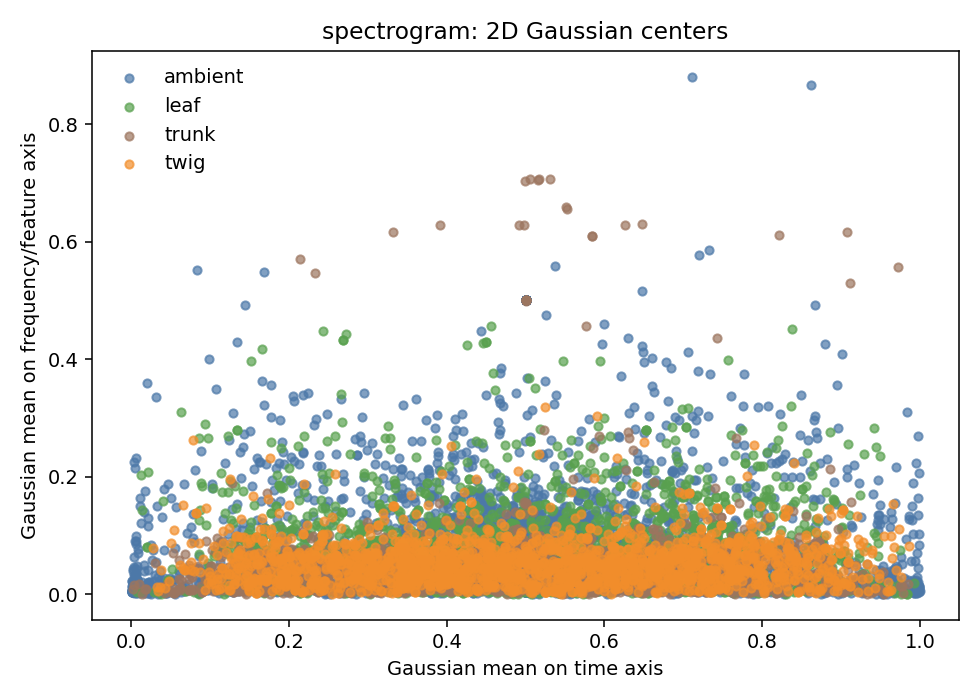

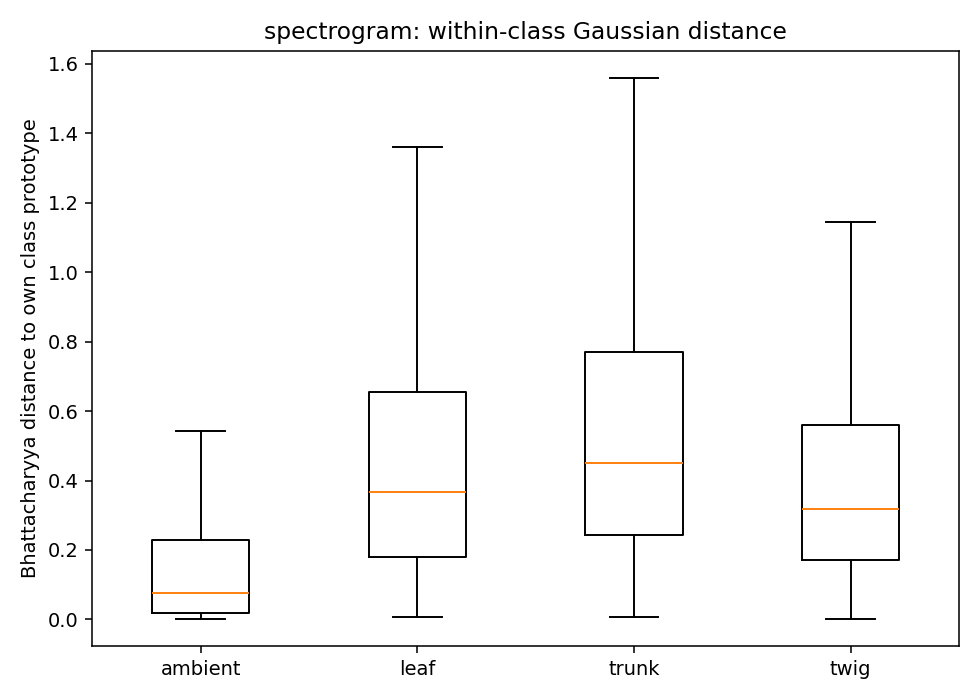

XGBoost skipped. Set TRAIN_XGBOOST=True in the config cell when you are ready to train.


In [8]:
from IPython.display import Image, display

feature_name = summary["feature"]
features_csv = OUTPUT_DIR / f"{feature_name}_gaussian_distance_features.csv"
distance_csv = OUTPUT_DIR / f"{feature_name}_gaussian_distance_by_label.csv"
metrics_json = OUTPUT_DIR / f"{feature_name}_gaussian_distance_xgboost_metrics.json"

features = pd.read_csv(features_csv)
print(f"Feature rows: {len(features)}")
display(features.head())

eda_cols = ["mu_freq", "mu_time", "std_freq", "std_time", "entropy", "nearest_gaussian_bhat"]
existing_cols = [col for col in eda_cols if col in features.columns]
if existing_cols:
    display(features.groupby(["split_role", "label"])[existing_cols].mean().round(4))

if distance_csv.exists():
    display(pd.read_csv(distance_csv).round(4))

for image_name in [
    f"{feature_name}_gaussian_mu_scatter.png",
    f"{feature_name}_gaussian_own_distance_boxplot.png",
]:
    image_path = OUTPUT_DIR / image_name
    if image_path.exists():
        display(Image(filename=str(image_path)))

if metrics_json.exists():
    display(json.loads(metrics_json.read_text()))
else:
    print("XGBoost skipped. Set TRAIN_XGBOOST=True in the config cell when you are ready to train.")


## Raw vs Gaussian comparison

Cell nay lay mot vai sample theo class, ve raw feature map da chuan hoa, Gaussian approximation tu `mu/cov` cua sample, va residual. Khong can train XGBoost.

,label,split,file,raw_vs_gaussian_l1,mass_overlap,rmse,cosine_similarity,raw_entropy,gaussian_entropy
0,ambient,val,umass_tree3_robot_trunk1_split_1_segment_3_win...,1.88098,0.05951,0.00064,0.09167,5.40534,9.38977
1,leaf,train,leaf4.5_segment_1_window_0_contact.wav,1.78069,0.10965,0.00057,0.14494,5.56453,8.61500
2,trunk,val,umass_tree1_robot_trunk2_segment_5_window_51_c...,1.82169,0.08916,0.00062,0.09743,5.56263,9.37333
3,twig,train,letwig1_11_segment_6_window_7_contact.wav,1.67970,0.16015,0.00034,0.23457,6.30333,8.47557


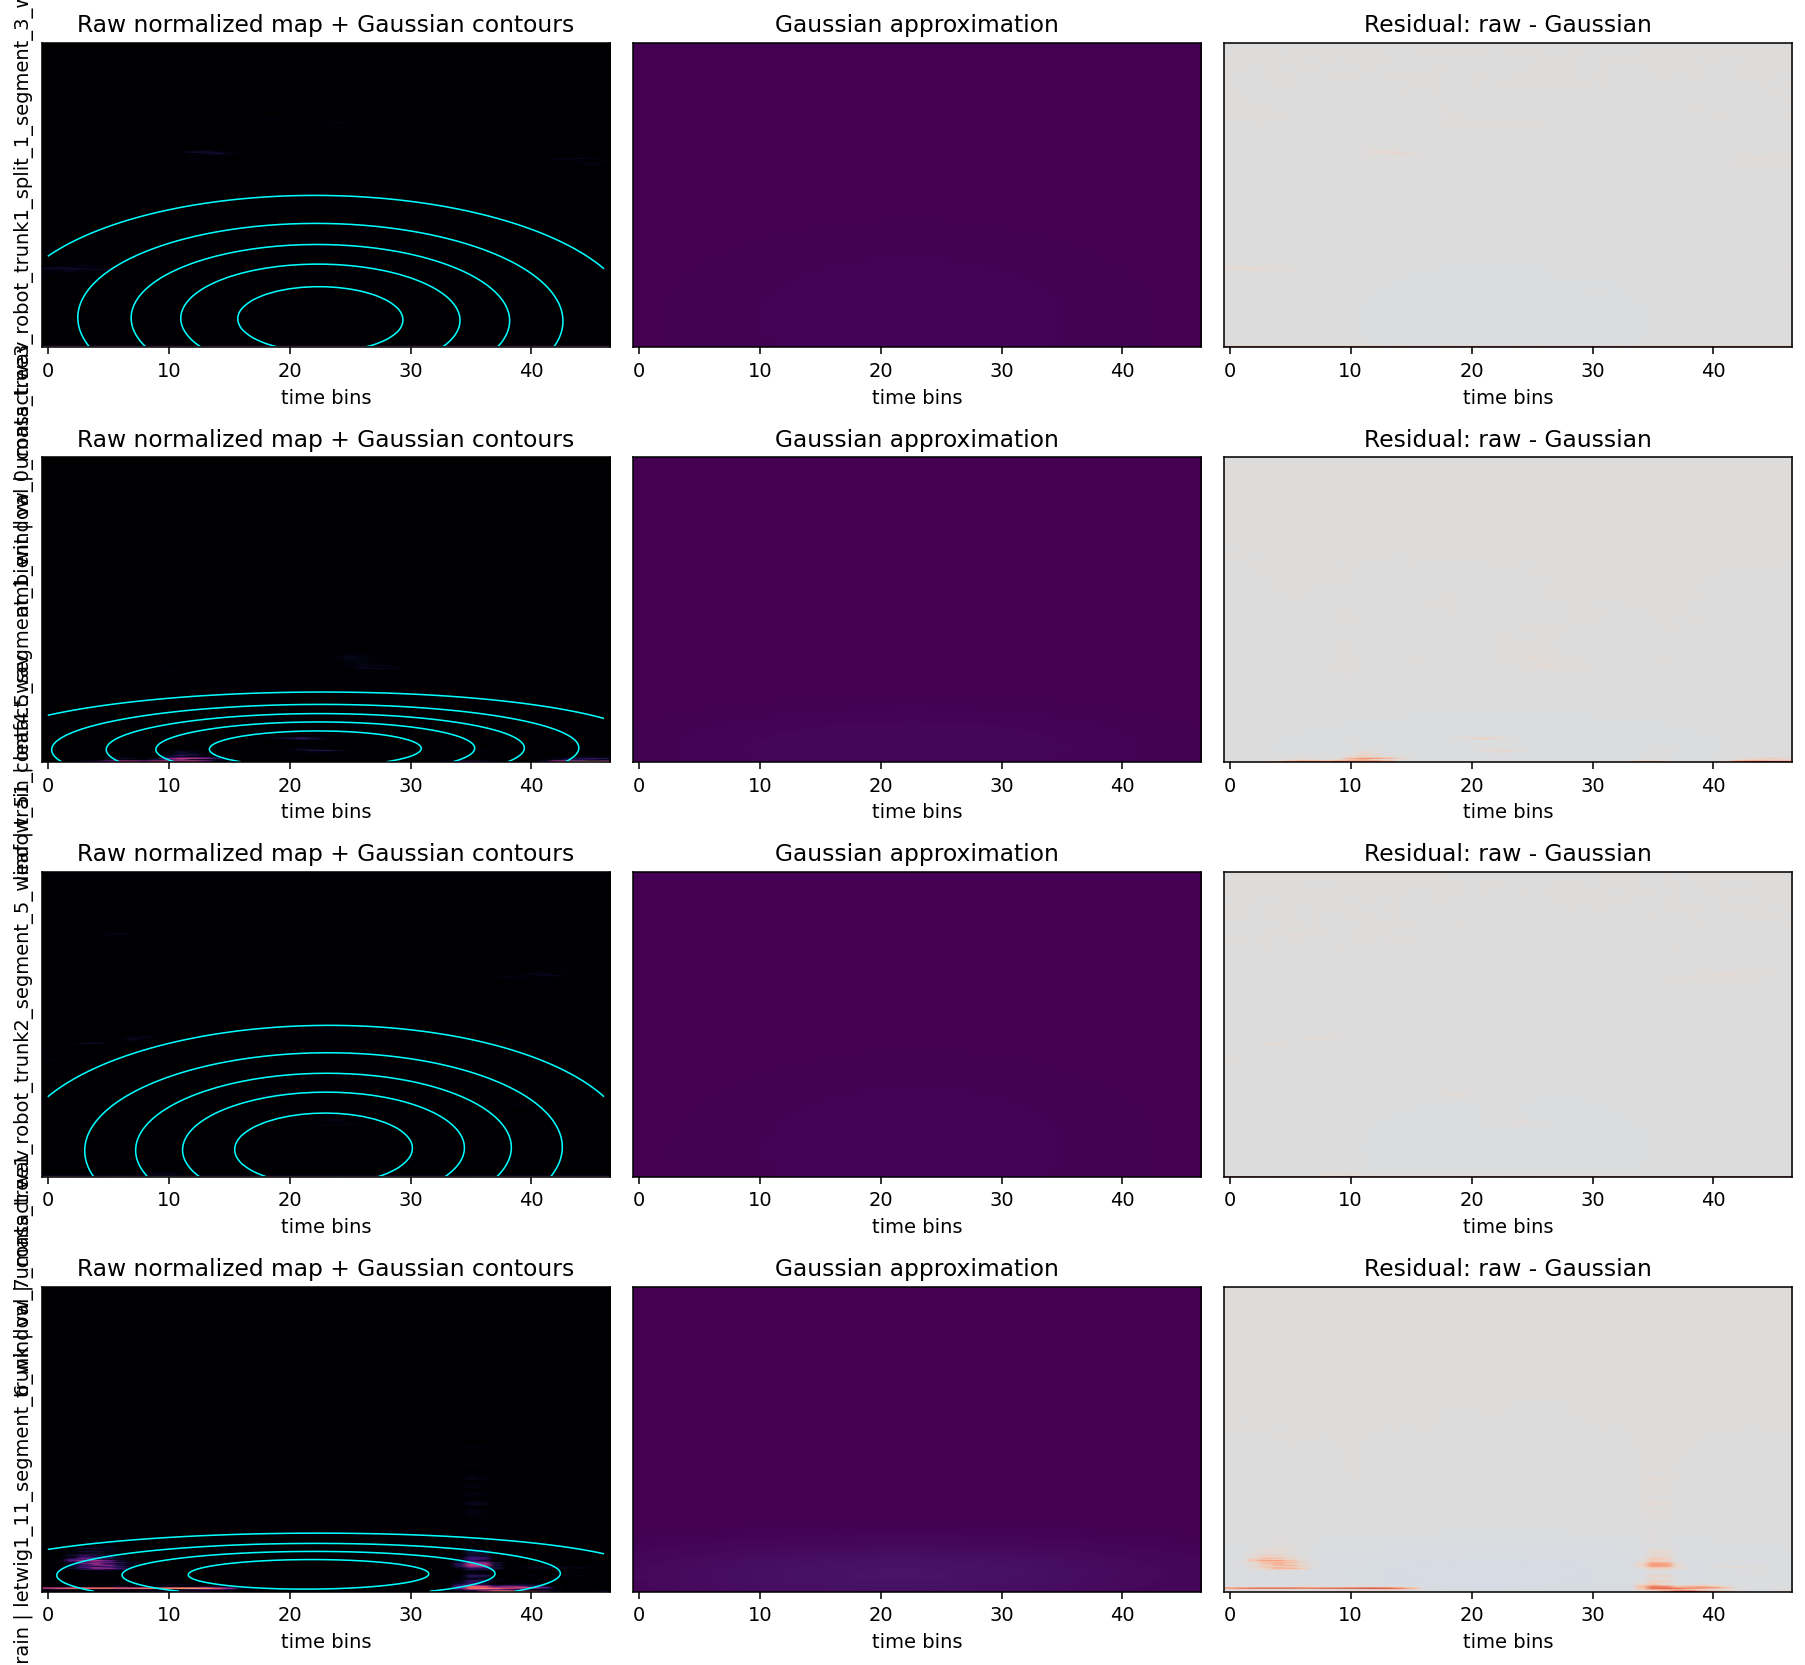

Saved: /kaggle/working/gaussian_spectrogram/spectrogram_raw_vs_gaussian_comparison.png


In [9]:
from IPython.display import display

COMPARE_SAMPLES_PER_CLASS = 1
EXTRACT_MAP_FOR_COMPARE = build_spectrogram_map


def gaussian_pdf_grid_from_row(row: pd.Series, shape: tuple[int, int]) -> np.ndarray:
    mu, cov = row_to_gaussian(row)
    n_freq, n_time = shape
    freq = np.linspace(0.0, 1.0, n_freq, dtype=np.float64)
    time = np.linspace(0.0, 1.0, n_time, dtype=np.float64)
    ff, tt = np.meshgrid(freq, time, indexing="ij")
    delta = np.stack([ff - mu[0], tt - mu[1]], axis=-1)
    inv_cov = np.linalg.inv(regularize_cov(cov))
    exponent = np.einsum("...i,ij,...j->...", delta, inv_cov, delta)
    gaussian = np.exp(-0.5 * np.clip(exponent, 0.0, 700.0))
    gaussian = gaussian + 1e-12
    return gaussian / gaussian.sum()


def raw_vs_gaussian_for_row(row: pd.Series, cfg: FeatureConfig) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict]:
    rng = np.random.default_rng(cfg.seed)
    audio = load_audio_window(row["audio_path"], cfg, rng)
    raw_map = EXTRACT_MAP_FOR_COMPARE(audio, cfg)
    raw_weight = map_to_weights(raw_map, cfg.weight_mode)
    gaussian_weight = gaussian_pdf_grid_from_row(row, raw_weight.shape)
    residual = raw_weight - gaussian_weight
    raw_flat = raw_weight.reshape(-1)
    gaussian_flat = gaussian_weight.reshape(-1)
    l1 = float(np.abs(residual).sum())
    metrics = {
        "label": row["label"],
        "split": row["split_role"],
        "file": Path(row["audio_path"]).name,
        "raw_vs_gaussian_l1": l1,
        "mass_overlap": float(1.0 - 0.5 * l1),
        "rmse": float(np.sqrt(np.mean(residual ** 2))),
        "cosine_similarity": float(
            np.dot(raw_flat, gaussian_flat)
            / (np.linalg.norm(raw_flat) * np.linalg.norm(gaussian_flat) + 1e-12)
        ),
        "raw_entropy": float(-np.sum(raw_flat * np.log(raw_flat + 1e-12))),
        "gaussian_entropy": float(-np.sum(gaussian_flat * np.log(gaussian_flat + 1e-12))),
    }
    return raw_weight, gaussian_weight, residual, metrics


feature_name = summary["feature"]
features_csv = OUTPUT_DIR / f"{feature_name}_gaussian_distance_features.csv"
features = pd.read_csv(features_csv)

chosen_rows = []
for label in LABELS:
    part = features[features["label"] == label]
    if part.empty:
        continue
    if "nearest_gaussian_bhat" in part.columns:
        part = part.sort_values("nearest_gaussian_bhat")
    chosen_rows.extend(part.head(COMPARE_SAMPLES_PER_CLASS).to_dict("records"))

cfg = FeatureConfig(
    target_sr=TARGET_SR,
    window_sec=WINDOW_SEC,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    n_mfcc=N_MFCC,
    crop_mode=CROP_MODE,
    weight_mode=WEIGHT_MODE,
    seed=SEED,
)

if CROP_MODE == "random":
    print("Note: CROP_MODE='random' means this preview may not reproduce exactly the same crop used during feature CSV extraction.")

comparison = []
metrics_rows = []
for item in chosen_rows:
    row = pd.Series(item)
    raw_weight, gaussian_weight, residual, metrics = raw_vs_gaussian_for_row(row, cfg)
    comparison.append((row, raw_weight, gaussian_weight, residual))
    metrics_rows.append(metrics)

metrics_frame = pd.DataFrame(metrics_rows)
display(metrics_frame.round(5))

try:
    import matplotlib.pyplot as plt

    if comparison:
        n_rows = len(comparison)
        fig, axes = plt.subplots(n_rows, 3, figsize=(13, max(3.2, 3.0 * n_rows)), dpi=140)
        if n_rows == 1:
            axes = np.asarray([axes])
        for row_idx, (row, raw_weight, gaussian_weight, residual) in enumerate(comparison):
            title = f"{row['label']} | {row['split_role']} | {Path(row['audio_path']).name}"
            vmax = max(float(raw_weight.max()), float(gaussian_weight.max()))
            axes[row_idx, 0].imshow(raw_weight, aspect="auto", origin="lower", cmap="magma", vmax=vmax)
            axes[row_idx, 0].contour(gaussian_weight, colors="cyan", linewidths=0.8, levels=5)
            axes[row_idx, 0].set_title("Raw normalized map + Gaussian contours")
            axes[row_idx, 0].set_ylabel(title)
            axes[row_idx, 1].imshow(gaussian_weight, aspect="auto", origin="lower", cmap="viridis", vmax=vmax)
            axes[row_idx, 1].set_title("Gaussian approximation")
            limit = float(np.max(np.abs(residual)))
            axes[row_idx, 2].imshow(residual, aspect="auto", origin="lower", cmap="coolwarm", vmin=-limit, vmax=limit)
            axes[row_idx, 2].set_title("Residual: raw - Gaussian")
            for col_idx in range(3):
                axes[row_idx, col_idx].set_xlabel("time bins")
                axes[row_idx, col_idx].set_yticks([])
        fig.tight_layout()
        out_path = OUTPUT_DIR / f"{feature_name}_raw_vs_gaussian_comparison.png"
        fig.savefig(out_path)
        display(plt.gcf())
        plt.close(fig)
        print(f"Saved: {out_path}")
except Exception as exc:
    print(f"Plotting skipped: {exc}")
